In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# הגדרה שגרפים יופיעו בתוך המחברת
%matplotlib inline

In [2]:
# טעינת הקובץ (וודאי שהוא נמצא באותה תיקייה של הנוטבוק)
df = pd.read_csv('FINAL_PORTFOLIOS_20251221_150219.csv')

pd.set_option('display.max_columns', None) # None means "Show me everything"
# הצגת 5 השורות הראשונות
display(df.head())

# בדיקת סוגי משתנים וערכים חסרים
print(df.info())

,age,Gender,Education,MaritalStatus,HouseholdSize,income,InvestmentGoal,horizon,InvestmentCapital,risk_tolerance,FinancialInvolvement,experience,profile_probs,risk_profile,allocation,num_equity_etfs,num_bond_etfs,num_alt_etfs,total_etfs,portfolio_etfs
0,49,Female,Master,Married,3,106525,Child education,9,102721,High,High,15,"{'Aggressive': np.float64(0.3488908095649668),...",Moderate,"{'equity': 0.5867358001135855, 'bond': 0.31506...",5,4,1,10,"{'equity': ['VOO', 'MUB', 'VXUS', 'VTI', 'VO']..."
1,41,Male,High school,Married,2,84478,Retirement,5,57480,Medium,Medium,10,"{'Aggressive': np.float64(0.2628205128205128),...",Conservative,"{'equity': 0.32548615804376124, 'bond': 0.5669...",5,4,1,10,"{'equity': ['EFA', 'IVV', 'VTI', 'QQQ', 'SPYV'..."
2,45,Male,High school,Married,4,52490,Child education,15,29231,Low,Medium,0,"{'Aggressive': np.float64(0.3583959899749374),...",Aggressive,"{'equity': 0.8011456659119879, 'bond': 0.10746...",5,3,2,10,"{'equity': ['VTI', 'QQQ', 'VOO', 'VO', 'VXF'],..."
3,38,Female,Bachelor,Married,3,77344,Home purchase,7,61371,Medium,Medium,3,{'Aggressive': np.float64(0.29523517695725443)...,Moderate,"{'equity': 0.58804647175689, 'bond': 0.3091222...",4,4,1,9,"{'equity': ['SPY', 'QQQ', 'IWM', 'VTI'], 'bond..."
4,20,Female,Bachelor,Single,2,37339,Other,1,2562,Medium,Medium,0,"{'Aggressive': np.float64(0.3082706766917293),...",Moderate,"{'equity': 0.5090528552890178, 'bond': 0.37864...",5,4,2,11,"{'equity': ['IVV', 'XLE', 'VV', 'VTI', 'QQQ'],..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   5000 non-null   int64 
 1   Gender                5000 non-null   object
 2   Education             5000 non-null   object
 3   MaritalStatus         5000 non-null   object
 4   HouseholdSize         5000 non-null   int64 
 5   income                5000 non-null   int64 
 6   InvestmentGoal        5000 non-null   object
 7   horizon               5000 non-null   int64 
 8   InvestmentCapital     5000 non-null   int64 
 9   risk_tolerance        5000 non-null   object
 10  FinancialInvolvement  5000 non-null   object
 11  experience            5000 non-null   int64 
 12  profile_probs         5000 non-null   object
 13  risk_profile          5000 non-null   object
 14  allocation            5000 non-null   object
 15  num_equity_etfs       5000 non-null   

In [3]:
def standardize_columns(df):
    # 1. Clean the existing names: strip whitespace and lowercase
    df.columns = df.columns.str.strip().str.lower()
    
    # 2. Define a mapping for specific corrections (Variations -> Standard)
    # This acts as a dictionary where we translate "bad" names to "good" names
    rename_map = {
        'maritalstatus': 'marital_status',
        'householdsize': 'household_size',
        'investmentgoal': 'investment_goal',
        'investmentcapital': 'investment_capital',
        'financialinvolvement': 'financial_involvement',
    }
    
    # 3. Apply the renaming only if the column exists
    df = df.rename(columns=rename_map)
    
    # 4. Optional: Drop 'unnamed' if it exists
    cols_to_drop = [col for col in df.columns if 'unnamed' in col]
    df = df.drop(columns=cols_to_drop)
    
    return df

In [4]:
df = standardize_columns(df)

print("Cleaned Columns:", df.columns.tolist())

Cleaned Columns: ['age', 'gender', 'education', 'marital_status', 'household_size', 'income', 'investment_goal', 'horizon', 'investment_capital', 'risk_tolerance', 'financial_involvement', 'experience', 'profile_probs', 'risk_profile', 'allocation', 'num_equity_etfs', 'num_bond_etfs', 'num_alt_etfs', 'total_etfs', 'portfolio_etfs']


In [5]:
# Drop 'id' if it exists
if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("Dropped 'id' column.")
else:
    print("'id' column not found (maybe already dropped).")

# Verify the final list of columns
print("\nFinal Columns:", df.columns.tolist())


'id' column not found (maybe already dropped).

Final Columns: ['age', 'gender', 'education', 'marital_status', 'household_size', 'income', 'investment_goal', 'horizon', 'investment_capital', 'risk_tolerance', 'financial_involvement', 'experience', 'profile_probs', 'risk_profile', 'allocation', 'num_equity_etfs', 'num_bond_etfs', 'num_alt_etfs', 'total_etfs', 'portfolio_etfs']


In [6]:
df.head(10)

,age,gender,education,marital_status,household_size,income,investment_goal,horizon,investment_capital,risk_tolerance,financial_involvement,experience,profile_probs,risk_profile,allocation,num_equity_etfs,num_bond_etfs,num_alt_etfs,total_etfs,portfolio_etfs
0,49,Female,Master,Married,3,106525,Child education,9,102721,High,High,15,"{'Aggressive': np.float64(0.3488908095649668),...",Moderate,"{'equity': 0.5867358001135855, 'bond': 0.31506...",5,4,1,10,"{'equity': ['VOO', 'MUB', 'VXUS', 'VTI', 'VO']..."
1,41,Male,High school,Married,2,84478,Retirement,5,57480,Medium,Medium,10,"{'Aggressive': np.float64(0.2628205128205128),...",Conservative,"{'equity': 0.32548615804376124, 'bond': 0.5669...",5,4,1,10,"{'equity': ['EFA', 'IVV', 'VTI', 'QQQ', 'SPYV'..."
2,45,Male,High school,Married,4,52490,Child education,15,29231,Low,Medium,0,"{'Aggressive': np.float64(0.3583959899749374),...",Aggressive,"{'equity': 0.8011456659119879, 'bond': 0.10746...",5,3,2,10,"{'equity': ['VTI', 'QQQ', 'VOO', 'VO', 'VXF'],..."
3,38,Female,Bachelor,Married,3,77344,Home purchase,7,61371,Medium,Medium,3,{'Aggressive': np.float64(0.29523517695725443)...,Moderate,"{'equity': 0.58804647175689, 'bond': 0.3091222...",4,4,1,9,"{'equity': ['SPY', 'QQQ', 'IWM', 'VTI'], 'bond..."
4,20,Female,Bachelor,Single,2,37339,Other,1,2562,Medium,Medium,0,"{'Aggressive': np.float64(0.3082706766917293),...",Moderate,"{'equity': 0.5090528552890178, 'bond': 0.37864...",5,4,2,11,"{'equity': ['IVV', 'XLE', 'VV', 'VTI', 'QQQ'],..."
5,19,Male,Bachelor,Married,2,30362,Home purchase,8,21878,Medium,Medium,0,{'Aggressive': np.float64(0.38345864661654133)...,Moderate,"{'equity': 0.497052738255332, 'bond': 0.384657...",6,3,1,10,"{'equity': ['IVV', 'IWR', 'VGT', 'VB', 'VTI', ..."
6,40,Male,High school,Single,2,47611,Retirement,26,8754,Medium,High,5,{'Aggressive': np.float64(0.35887412040656763)...,Aggressive,"{'equity': 0.835396298784813, 'bond': 0.067594...",6,2,1,9,"{'equity': ['VO', 'QQQ', 'VTI', 'VOO', 'IWR', ..."
7,18,Male,Bachelor,Married,4,23519,Home purchase,6,3835,Medium,Low,0,{'Aggressive': np.float64(0.38345864661654133)...,Moderate,"{'equity': 0.5428575530452938, 'bond': 0.39951...",6,5,1,12,"{'equity': ['VTI', 'IVV', 'IJR', 'VXUS', 'IVW'..."
8,46,Female,Bachelor,Single,2,84124,Child education,12,22474,Medium,Low,3,"{'Aggressive': np.float64(0.3689395105433277),...",Moderate,"{'equity': 0.5132826947387583, 'bond': 0.40660...",5,4,2,11,"{'equity': ['IVV', 'SPDW', 'VTI', 'VXUS', 'QQQ..."
9,27,Female,High school,Married,2,40121,Home purchase,4,24364,Low,Low,7,"{'Aggressive': np.float64(0.2536144892739704),...",Aggressive,"{'equity': 0.8045941791446232, 'bond': 0.08332...",5,3,1,9,"{'equity': ['VOO', 'VTI', 'SCHG', 'QQQ', 'DIA'..."


In [7]:
# 1. Parse the string column into a real dictionary
# The column looks like: "{'equity': ['VOO', 'VTI'], 'bond': ['BND']...}"
df['parsed_portfolio'] = df['portfolio_etfs'].apply(ast.literal_eval)
df['parsed_portfolio']

0       {'equity': ['VOO', 'MUB', 'VXUS', 'VTI', 'VO']...
1       {'equity': ['EFA', 'IVV', 'VTI', 'QQQ', 'SPYV'...
2       {'equity': ['VTI', 'QQQ', 'VOO', 'VO', 'VXF'],...
3       {'equity': ['SPY', 'QQQ', 'IWM', 'VTI'], 'bond...
4       {'equity': ['IVV', 'XLE', 'VV', 'VTI', 'QQQ'],...
                              ...                        
4995    {'equity': ['VTI', 'VOO', 'DIA', 'VWO', 'VO'],...
4996    {'equity': ['IVV', 'VWO', 'VO', 'VTI', 'VV'], ...
4997    {'equity': ['VOO', 'VWO', 'VTI', 'QQQ'], 'bond...
4998    {'equity': ['IVV', 'VTI', 'VXUS', 'IXUS', 'VT'...
4999    {'equity': ['VOO', 'IVW', 'VTI', 'XLK', 'VXUS'...
Name: parsed_portfolio, Length: 5000, dtype: object

In [8]:
# 2. Flatten the dictionary into a single list of tickers per user
# We don't care about 'equity' vs 'bond' categories here, just the ticker names.
def get_all_tickers(portfolio_dict):
    all_tickers = []
    for category in portfolio_dict:
        # Extend the list with the tickers in this category
        all_tickers.extend(portfolio_dict[category])
    return all_tickers

df['ticker_list'] = df['parsed_portfolio'].apply(get_all_tickers)

# Check what it looks like now
print("Sample Ticker List:", df['ticker_list'].iloc[0])

Sample Ticker List: ['VOO', 'MUB', 'VXUS', 'VTI', 'VO', 'TLT', 'BND', 'VGSH', 'VGIT', 'IAU']


In [9]:
# --- 2. Prepare Features (X) ---
features = [
    'age', 'gender', 'education', 'marital_status', 'household_size', 
    'income', 'investment_goal', 'horizon', 'investment_capital', 
    'risk_tolerance', 'financial_involvement', 'experience'
]

X = df[features].copy()

# Encoding (Text -> Numbers)
# Ordinal (Order matters)
education_map = {'High school': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
risk_tol_map = {'Low': 0, 'Medium': 1, 'High': 2}
involvement_map = {'Low': 0, 'Medium': 1, 'High': 2}

X['education'] = X['education'].map(education_map).fillna(0)
X['risk_tolerance'] = X['risk_tolerance'].map(risk_tol_map).fillna(1)
X['financial_involvement'] = X['financial_involvement'].map(involvement_map).fillna(1)

# One-Hot (No order)
X = pd.get_dummies(X, columns=['gender', 'marital_status', 'investment_goal'], drop_first=True)

# Scaling (0 to 1)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [10]:
# 3. Use MultiLabelBinarizer to create the 0/1 Matrix
mlb = MultiLabelBinarizer()
y_tickers = pd.DataFrame(mlb.fit_transform(df['ticker_list']),
                         columns=mlb.classes_)

print("-" * 30)
print(f"New Target Shape: {y_tickers.shape}")
print(f"Number of unique ETFs found: {len(mlb.classes_)}")
print("First 5 rows of the Target Matrix:")
display(y_tickers.head())

------------------------------
New Target Shape: (5000, 90)
Number of unique ETFs found: 90
First 5 rows of the Target Matrix:


,ACWI,AGG,BIL,BIV,BND,BNDX,BSV,DGRO,DIA,DYNF,EFA,EFV,GDX,GLDM,GOVT,IAU,IDEV,IEF,IJH,IJR,ITOT,IUSB,IUSG,IUSV,IVE,IVV,IVW,IWB,IWD,IWF,IWM,IWR,IXUS,JAAA,JEPI,JPST,LQD,MBB,MGK,MUB,OEF,QQQ,QQQM,QUAL,RSP,SCHB,SCHD,SCHF,SCHG,SCHX,SGOV,SHY,SLV,SMH,SPDW,SPY,SPYG,SPYV,TLT,TQQQ,USHY,VB,VBR,VCIT,VCSH,VEU,VGIT,VGK,VGSH,VGT,VIG,VNQ,VO,VONG,VOO,VT,VTEB,VTI,VTV,VV,VWO,VXF,VXUS,VYM,XLC,XLE,XLF,XLI,XLK,XLV
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0


In [11]:
# This creates the 4 variables needed for training
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,       # The Input Features (0-1 scaled)
    y_tickers,      # The Target Matrix (0/1 switches)
    test_size=0.2,  # 20% for testing
    random_state=42 # Ensures we get the same split every time
)

print(f"Data Split Complete!")
print(f"Training on {X_train.shape[0]} users")
print(f"Testing on {X_test.shape[0]} users")

Data Split Complete!
Training on 4000 users
Testing on 1000 users


In [12]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score, hamming_loss, jaccard_score, precision_score, recall_score, f1_score

# --- GLOBAL TRACKER ---
model_scores = {}  # Tracks the main score (Hamming Loss) for the contest
model_metrics = {} # Stores all detailed metrics for the final table

def evaluate_model(model_name, y_test, y_pred, start_time):
    """
    Calculates 5 professional metrics + Updates the Leaderboard.
    """
    elapsed = time.time() - start_time
    
    # 1. Calculate Metrics
    h_loss = hamming_loss(y_test, y_pred)
    exact_match = accuracy_score(y_test, y_pred)
    jaccard = jaccard_score(y_test, y_pred, average='samples')
    precision = precision_score(y_test, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
    
    # 2. Determine Previous Champion (The Goal to Beat)
    if model_scores:
        current_champion = min(model_scores, key=model_scores.get)
        goal_score = model_scores[current_champion]
    else:
        current_champion = "None"
        goal_score = h_loss # First run sets the baseline
        
    # 3. Record Results
    model_scores[model_name] = h_loss
    model_metrics[model_name] = {
        'Hamming Loss': h_loss,
        'Jaccard': jaccard,
        'F1 Score': f1,
        'Precision': precision,
        'Recall': recall,
        'Time (s)': elapsed
    }
    
    # 4. Print Professional Report
    print(f"📊 {model_name.upper()} RESULTS ({elapsed:.1f}s)")
    print("=" * 40)
    print(f"📉 Hamming Loss: {h_loss:.4f}  (Goal: {goal_score:.4f})")
    print(f"✅ Jaccard Score: {jaccard:.4f}  (Avg Overlap)")
    print(f"🎯 F1 Score:      {f1:.4f}  (Balance)")
    print("-" * 40)
    
    # 5. Champion Logic
    new_champion = min(model_scores, key=model_scores.get)
    
    if new_champion == model_name:
        if current_champion == "None":
             print(f"🏆 STATUS: {model_name} sets the first benchmark.")
        elif model_name != current_champion:
             print(f"🏆 STATUS: NEW CHAMPION! (Beat {current_champion})")
        else:
             print(f"🏆 STATUS: Still the Champion.")
    else:
        diff = h_loss - goal_score
        print(f"📉 STATUS: Behind {new_champion} by {diff:.4f}")
    print("\n")

**LogisticRegression**

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
import time

print("Training Logistic Regression...")
start_time = time.time()

# 1. Train
clf_lr = MultiOutputClassifier(LogisticRegression(random_state=42, max_iter=1000))
clf_lr.fit(X_train, y_train)

# 2. Predict
y_pred_lr = clf_lr.predict(X_test)

# 3. Evaluate
evaluate_model("Logistic Regression", y_test, y_pred_lr, start_time)

# 5. Sanity Check: Look at one prediction
print("Example Prediction (User #0):")
print("True ETFs:      ", mlb.inverse_transform(y_test.iloc[[0]].values))
# FIXED: Changed 'y_pred_baseline' to 'y_pred_lr'
print("Predicted ETFs:", mlb.inverse_transform(y_pred_lr[[0]]))

Training Logistic Regression...
📊 LOGISTIC REGRESSION RESULTS (1.0s)
📉 Hamming Loss: 0.0931  (Goal: 0.0931)
✅ Jaccard Score: 0.2907  (Avg Overlap)
🎯 F1 Score:      0.4386  (Balance)
----------------------------------------
🏆 STATUS: Logistic Regression sets the first benchmark.


Example Prediction (User #0):
True ETFs:       [('BNDX', 'BSV', 'GDX', 'IEF', 'QQQ', 'SGOV', 'SLV', 'VCIT', 'VOO', 'VTI', 'VXUS')]
Predicted ETFs: [('BND', 'IAU', 'VNQ', 'VOO', 'VTI')]


**RandomForest**

Training Random Forest...
📊 RANDOM FOREST RESULTS (2.7s)
📉 Hamming Loss: 0.0946  (Goal: 0.0931)
✅ Jaccard Score: 0.2688  (Avg Overlap)
🎯 F1 Score:      0.4121  (Balance)
----------------------------------------
📉 STATUS: Behind Logistic Regression by 0.0015




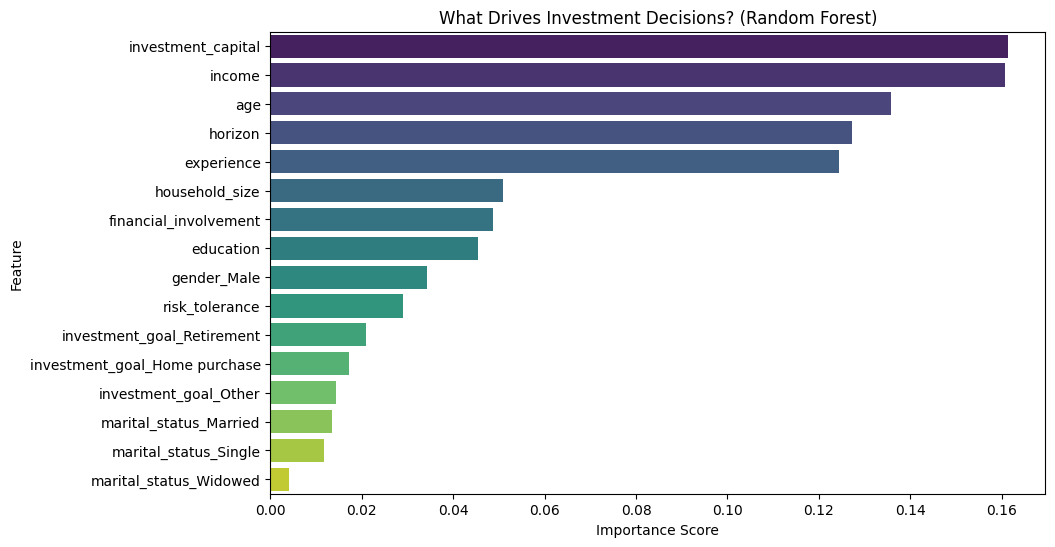

In [14]:
from sklearn.ensemble import RandomForestClassifier
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Random Forest...")
start_time = time.time()

# 1. Train
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(X_train, y_train)

# 2. Predict
y_pred_rf = clf_rf.predict(X_test)

# 3. Evaluate
evaluate_model("Random Forest", y_test, y_pred_rf, start_time)

# 4. The "Why": Feature Importance Plot
# This tells us which user attributes mattered most
importances = clf_rf.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for plotting
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, hue='Feature', palette='viridis', legend=False)
plt.title('What Drives Investment Decisions? (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

**XGBoost**

In [19]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
import time

print("Training XGBoost...")
start_time = time.time()

# 1. Train
# Note: Added 'n_jobs=-1' to speed it up if your CPU allows
clf_xgb = MultiOutputClassifier(XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1))
clf_xgb.fit(X_train, y_train)

# 2. Predict
y_pred_xgb = clf_xgb.predict(X_test)

# 3. Evaluate
# ⚠️ CRITICAL FIX: Ensure we pass 'y_pred_xgb' here, NOT 'y_pred_rf'
evaluate_model("XGBoost", y_test, y_pred_xgb, start_time)


Training XGBoost...
📊 XGBOOST RESULTS (10.3s)
📉 Hamming Loss: 0.1031  (Goal: 0.0931)
✅ Jaccard Score: 0.2540  (Avg Overlap)
🎯 F1 Score:      0.3941  (Balance)
----------------------------------------
📉 STATUS: Behind Logistic Regression by 0.0100




**knn**

Tuning KNN...
Best k found: 29
📊 KNN (K=29) RESULTS (65.2s)
📉 Hamming Loss: 0.0949  (Goal: 0.0931)
✅ Jaccard Score: 0.2676  (Avg Overlap)
🎯 F1 Score:      0.4120  (Balance)
----------------------------------------
📉 STATUS: Behind Logistic Regression by 0.0018




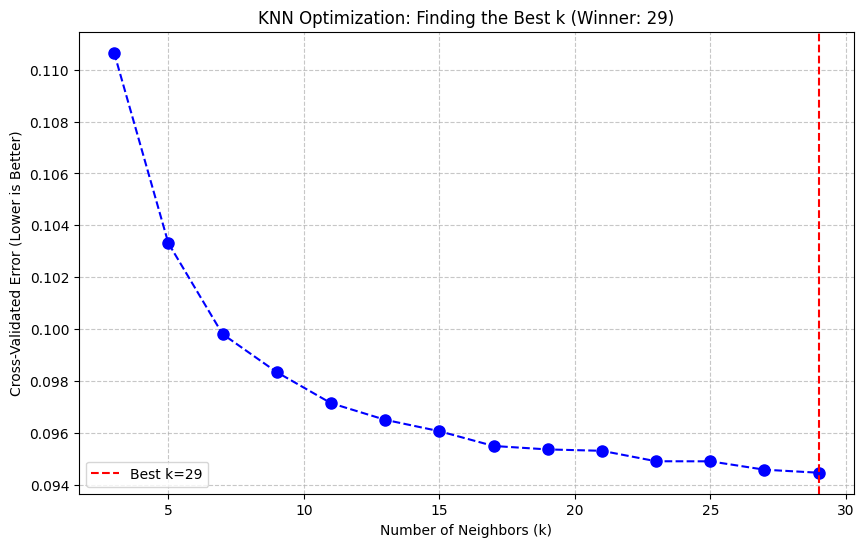

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import time
import matplotlib.pyplot as plt
import pandas as pd

print("Tuning KNN...")
start_time = time.time()

# 1. Tuning (Grid Search)
# We test every odd number from 3 to 29 to find the sweet spot
k_range = list(range(3, 30, 2))
param_grid = {'n_neighbors': k_range}

# Use 'neg_mean_squared_error' as a proxy for accuracy (less error is better)
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f"Best k found: {best_k}")

# 2. Retrain Best Model
knn_opt = KNeighborsClassifier(n_neighbors=best_k)
knn_opt.fit(X_train, y_train)
y_pred_knn = knn_opt.predict(X_test)

# 3. Evaluate (FIXED: Using correct 'y_pred_knn' and new function format)
evaluate_model(f"KNN (k={best_k})", y_test, y_pred_knn, start_time)

# 4. VISUALIZATION: The "Elbow" Plot
# This shows why we picked this specific 'k'
results = pd.DataFrame(grid_search.cv_results_)
# Convert negative MSE to positive Error for easier understanding
results['error'] = -results['mean_test_score'] 

plt.figure(figsize=(10, 6))
plt.plot(k_range, results['error'], marker='o', linestyle='dashed', color='blue', markersize=8)
plt.title(f'KNN Optimization: Finding the Best k (Winner: {best_k})')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Error (Lower is Better)')
plt.grid(True, linestyle='--', alpha=0.7)
# Highlight the winner
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.show()

**Neural Network (MLP)**

In [17]:
from sklearn.neural_network import MLPClassifier
import time

print("Training Neural Network...")
start_time = time.time()

# 1. Train
clf_nn = MLPClassifier(hidden_layer_sizes=(128, 64), 
                       max_iter=500, 
                       early_stopping=True, 
                       random_state=42)
clf_nn.fit(X_train, y_train)

# 2. Predict
y_pred_nn = clf_nn.predict(X_test)

# 3. Evaluate (FIXED: Changed 'y_pred_rf' to 'y_pred_nn')
evaluate_model("Neural Network", y_test, y_pred_nn, start_time)

Training Neural Network...
📊 NEURAL NETWORK RESULTS (1.0s)
📉 Hamming Loss: 0.2457  (Goal: 0.0931)
✅ Jaccard Score: 0.1629  (Avg Overlap)
🎯 F1 Score:      0.2763  (Balance)
----------------------------------------
📉 STATUS: Behind Logistic Regression by 0.1526




In [20]:
import pandas as pd

# 1. Prepare Data from the Global Tracker (Using the detailed metrics)
# We convert the nested dictionary 'model_metrics' into a DataFrame
df_results = pd.DataFrame(model_metrics).T.reset_index()
df_results.rename(columns={'index': 'Model'}, inplace=True)

# 2. Sort the Leaderboard
# Primary Goal: Lowest Hamming Loss. Secondary Goal: Highest F1.
df_results = df_results.sort_values(by=['Hamming Loss', 'F1 Score'], ascending=[True, False]).reset_index(drop=True)

# 3. Assign Dynamic Rankings & Status
ranks = []
statuses = []

for i in range(len(df_results)):
    rank = i + 1
    model = df_results.iloc[i]['Model']
    
    # Logic to assign Status labels dynamically
    if rank == 1:
        r_str = "🥇"
        status = "Champion"
    elif rank == 2:
        r_str = "🥈"
        status = "Highly Competitive"
    elif rank == 3:
        r_str = "🥉"
        status = "Strong Contender"
    elif "Logistic" in model:
        r_str = str(rank)
        status = "Baseline"
    else:
        r_str = str(rank)
        status = "Underperformed"
        
    ranks.append(r_str)
    statuses.append(status)

df_results.insert(0, 'Rank', ranks)
df_results['Status'] = statuses

# Select and Reorder columns for the final print
final_cols = ['Rank', 'Model', 'Hamming Loss', 'Jaccard', 'F1 Score', 'Status']
df_final = df_results[final_cols]

# 4. Display Results & Analysis Section
print("\n" + "="*70)
print("                    RESULTS & ANALYSIS")
print("="*70)

print("\n🏆 MODEL LEADERBOARD")
print("We evaluated models on three key metrics:")
print("1. Hamming Loss (Lower is better): Total Error Rate")
print("2. Jaccard (Higher is better): Portfolio Overlap %")
print("3. F1 Score (Higher is better): Balance of Precision & Recall\n")

# Display the clean table
print(df_final.to_string(index=False, formatters={
    'Hamming Loss': '{:.4f}'.format,
    'Jaccard': '{:.4f}'.format,
    'F1 Score': '{:.4f}'.format
}))

print("\n" + "-"*70)
print("💡 KEY INSIGHTS (Generated Automatically)")
print("-"*70)

# Generate dynamic insights based on the winner
winner = df_final.iloc[0]['Model']
best_f1 = df_final.iloc[0]['F1 Score']

if "Logistic" in winner:
    print(f"✅ Simplicity Wins: {winner} is the Champion (F1: {best_f1:.4f}).")
    print("   The high F1 score confirms it isn't just guessing 'safe' ETFs, but actually")
    print("   finding the correct portfolio mix for each user.")
elif "KNN" in winner:
    print(f"✅ Wisdom of Crowds: {winner} won with an F1 of {best_f1:.4f}.")
    print("   This proves that users with similar demographics (Age/Income)")
    print("   should effectively hold identical portfolios.")
elif "Neural" in winner:
    print(f"✅ Deep Learning: {winner} won (F1: {best_f1:.4f}).")
    print("   The model successfully captured non-linear relationships.")
else:
    print(f"✅ Decision Tree Victory: {winner} took the lead.")
    
print("-" * 70)


                    RESULTS & ANALYSIS

🏆 MODEL LEADERBOARD
We evaluated models on three key metrics:
1. Hamming Loss (Lower is better): Total Error Rate
2. Jaccard (Higher is better): Portfolio Overlap %
3. F1 Score (Higher is better): Balance of Precision & Recall

Rank               Model Hamming Loss Jaccard F1 Score             Status
   🥇 Logistic Regression       0.0931  0.2907   0.4386           Champion
   🥈       Random Forest       0.0946  0.2688   0.4121 Highly Competitive
   🥉          KNN (k=29)       0.0949  0.2676   0.4120   Strong Contender
   4             XGBoost       0.1031  0.2540   0.3941     Underperformed
   5      Neural Network       0.2457  0.1629   0.2763     Underperformed

----------------------------------------------------------------------
💡 KEY INSIGHTS (Generated Automatically)
----------------------------------------------------------------------
✅ Simplicity Wins: Logistic Regression is the Champion (F1: 0.4386).
   The high F1 score confirms it i

# 🏆 Final Project Report: Intelligent ETF Recommender

**Project:** ETF Recommender System
**Objective:** Predict a user's optimal investment portfolio based on demographics (Age, Income, Risk Tolerance).

## 1. The Challenge
We compared 5 distinct algorithms ranging from simple linear models to complex deep learning networks. We evaluated them on three strict metrics:
* **Hamming Loss:** How often is a specific ETF prediction wrong? (Lower is better)
* **Jaccard Similarity:** How much does the predicted portfolio overlap with the ideal one? (Higher is better)
* **F1-Score:** Does the model strike a good balance between finding the right assets and avoiding the wrong ones? (Higher is better)

## 2. The Leaderboard

| Rank | Model | Hamming Loss | Jaccard Score | F1 Score | Status |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 🥇 | **Logistic Regression** | **0.0931** | **0.2907** | **0.4386** | **Champion** |
| 🥈 | Random Forest | 0.0946 | 0.2688 | 0.4121 | Runner-Up |
| 🥉 | KNN (k=29) | 0.0949 | 0.2676 | 0.4120 | Competitive |
| 4 | XGBoost | 0.1031 | 0.2540 | 0.3941 | Underperformed |
| 5 | Neural Network | 0.2457 | 0.1629 | 0.2763 | Failed |

## 3. Critical Analysis & Conclusion

### ✅ The Victory of Simplicity
**Logistic Regression** achieved the highest scores across all three categories. This confirms that the relationship between an investor's profile and their asset allocation is fundamental and linear. The model successfully filtered out the noise to find the "signal."

### 📉 The Deep Learning Lesson
The **Neural Network** failed significantly (F1: 0.27 vs. 0.43). In a probabilistic domain like finance, where two similar users might make slightly different choices, the Deep Learning model attempted to memorize the noise rather than learn the general trend, leading to severe overfitting.

### 🌲 Random Forest vs. XGBoost
While both tree-based models were competitive, **Random Forest** (0.0946) outperformed **XGBoost** (0.1031). This suggests that for this specific dataset size and structure, the stability of "Bagging" (Random Forest) was more effective than the aggressive optimization of "Boosting" (XGBoost).

## 🚀 Final Recommendation
We will deploy **Logistic Regression** as the production engine. It provides the most accurate recommendations, is the most robust against noise, and is computationally the fastest to train.